# ASSIGNMENT 2: kNN classifier

## Business understanding - Anni

## Data understanding - Sandra

In [7]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17) 
  
# data (as pandas dataframes) 
X = breast_cancer_wisconsin_diagnostic.data.features 
#y = breast_cancer_wisconsin_diagnostic.data.targets 
y = breast_cancer_wisconsin_diagnostic.data.targets['Diagnosis']

In [8]:
X

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [9]:
y

0      M
1      M
2      M
3      M
4      M
      ..
564    M
565    M
566    M
567    M
568    B
Name: Diagnosis, Length: 569, dtype: object

In [10]:
import pandas as pd
import numpy as np

X.dtypes - kaikki datatyppi on float

In [11]:
breast_cancer_wisconsin_diagnostic.variables

,name,role,type,demographic,description,units,missing_values
0,ID,ID,Categorical,None,None,None,no
1,Diagnosis,Target,Categorical,None,None,None,no
2,radius1,Feature,Continuous,None,None,None,no
3,texture1,Feature,Continuous,None,None,None,no
4,perimeter1,Feature,Continuous,None,None,None,no
5,area1,Feature,Continuous,None,None,None,no
6,smoothness1,Feature,Continuous,None,None,None,no
7,compactness1,Feature,Continuous,None,None,None,no
8,concavity1,Feature,Continuous,None,None,None,no
9,concave_points1,Feature,Continuous,None,None,None,no


## Data preparation (Riikka)

The provided data is fairly clean with no missing values or any outliers, so there is no need for clean up. All 30 provided features are also kept so nothing was changed from the original dataframe.

Since split validation is going to be the validation method for testing the model's performance, the original dataframe will be split into training and testing sets. <br> The provided dataset is split into test and training sets in 3:7 ratio using the `train_test_split` function from `Scikit-learn` library. 30% of the data is set aside for testing and 70% is used to train the model. The random seed used in the split for the split is 123. <br> The split is done before the scaling of the values so to avoid data leakage. The test set needs to contain new and unfamiliar data so that the model's performance can be properly tested. If the scaling was performed before the split, the model would get preliminary information about the test set. This may make the model's performance look overly optimistic when using the test data. 

In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=123)

Scaling of the training and test sets is done with standardization. `Scikit-learn` library's `StandardScaler` class is used to perform the scaling using the standardization process. <br> First the training set is scaled using the `fit_transform` method. This method calculates the mean average and standard deviation values for all the columns and uses the calculated values to scale all tha values in the columns. The calculated values are stored in the `StandardScaler` object so it can be used to scale the test set.

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns) # preserves column names
X_train_scaled

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,-0.754501,1.016591,-0.731287,-0.732655,-0.244628,-0.046204,0.276113,-0.209613,-1.463648,0.393141,...,-0.786560,1.835601,-0.748038,-0.715894,-0.048296,0.013325,0.464941,-0.272555,-1.224122,0.246375
1,-0.107318,-1.377551,-0.167357,-0.212302,-0.290236,-0.806690,-0.982285,-0.780715,-0.758709,-0.498156,...,-0.330400,-1.399872,-0.391399,-0.384622,-0.624296,-0.968536,-1.127291,-0.871529,-0.081993,-0.899752
2,0.872048,0.598852,0.813064,0.791235,0.092006,-0.277838,0.018477,0.422567,0.191577,-0.947868,...,1.108900,0.583315,0.998261,0.988855,1.121705,0.047299,0.591565,1.311903,0.549310,-0.440828
3,-0.084408,-0.492662,-0.151531,-0.194880,-0.589225,-0.822895,-0.937614,-0.983264,-0.682686,-0.527956,...,-0.159600,-0.336308,-0.207531,-0.269767,-0.682796,-0.779638,-0.913008,-0.980094,-0.819317,-0.670290
4,1.436186,1.616250,1.421142,1.400153,0.435156,0.777386,1.288387,1.241373,0.312522,-0.080953,...,1.554646,1.634084,1.577161,1.499322,2.129706,0.912967,1.503354,1.137701,0.616777,0.830675
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
393,-0.728728,-1.474125,-0.738784,-0.706231,-0.445884,-0.558088,-0.590263,-0.406680,-0.661953,0.409395,...,-0.665750,-1.363087,-0.727641,-0.648009,0.550204,-0.439214,-0.370091,-0.459822,-0.163918,0.260568
394,-0.367909,-1.366321,-0.385599,-0.438505,1.260452,-0.308532,-0.639813,-0.393629,-0.928033,0.265813,...,-0.461624,-0.736144,-0.432492,-0.493805,1.072205,-0.181009,-0.434136,0.022499,-0.790402,0.140515
395,-0.599864,0.744836,-0.555111,-0.604019,-1.928521,0.052932,-0.121414,-0.503778,-2.102931,0.513696,...,-0.767814,0.484155,-0.595664,-0.690725,-1.929747,0.486928,0.113915,-0.075490,-1.097219,0.611267
396,1.802732,0.533720,1.737676,1.850235,-0.324985,0.163507,0.110821,0.750925,-0.668864,-0.979023,...,1.677538,0.109909,1.619153,1.598580,0.082204,-0.082483,0.011247,0.971276,-0.425756,-0.934645


The test set is scaled using the same `StandardScaler` object that was used to scale the training set. The `transform` method scales the values in the test set based on the values it has previously calculated and stored. This method is used because it does the scaling but does not recalculate the values used for the scaling which would make the values in the test set incorrect.

In [14]:
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_train_scaled.columns)
X_test_scaled

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,-0.828956,-1.038418,-0.862066,-0.771856,-0.935994,-1.142798,-1.103111,-1.204318,-0.133248,-0.269236,...,-0.728238,-0.579409,-0.754037,-0.683103,-0.642296,-1.031457,-1.282769,-1.514676,-0.094844,-0.530721
1,-1.260793,-0.838532,-1.273560,-1.062522,-0.406791,-1.098759,-0.977280,-0.913833,0.931071,0.043666,...,-1.146906,-0.768131,-1.173664,-0.926816,0.712205,-1.060267,-1.112086,-0.971540,-0.053079,-0.083033
2,0.972276,-0.018774,0.958836,0.858893,-0.456743,0.291239,0.181017,0.673403,-1.055889,-1.068424,...,0.867281,0.025143,0.968266,0.639681,0.325204,0.626903,0.405296,1.241911,0.086675,-0.265184
3,-0.324954,0.632540,-0.419335,-0.375784,-2.423699,-1.623226,-1.095336,-1.232742,-1.439459,-1.416544,...,-0.469956,0.533735,-0.571068,-0.477321,-2.233047,-1.463747,-1.270747,-1.629944,-0.930156,-1.462171
4,1.235731,-0.198447,1.208731,1.217216,0.199150,0.014803,0.555145,1.014551,1.107306,-0.349155,...,1.390095,0.319423,1.349200,1.284855,0.401704,-0.277496,0.233694,0.779965,1.318760,0.155891
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166,-2.051445,-1.341616,-2.011167,-1.487632,1.521072,-0.549890,-1.115294,-1.281082,0.409278,2.083625,...,-1.734290,-0.982443,-1.703972,-1.228134,1.238705,-0.880202,-1.309746,-1.773956,0.093101,0.630783
167,0.605730,0.556179,0.642303,0.496504,1.484875,0.453288,1.135732,0.802084,0.198488,0.341668,...,0.306975,-0.075615,0.194400,0.172107,0.527704,-0.259150,0.325117,-0.145481,-0.221748,-0.214323
168,1.410413,1.214231,1.508605,1.301425,-0.374937,2.182446,1.521122,1.318895,1.722400,0.085657,...,1.631714,1.197463,2.105069,1.369933,-0.277796,3.361164,2.230829,2.103587,2.884970,1.220997
169,1.728278,0.030636,1.737676,1.725374,1.253212,0.846019,1.553655,2.005105,-0.302572,-0.307164,...,1.202632,-0.098006,1.163232,1.065070,1.603205,0.302107,1.285307,1.605868,0.253738,-0.142173


## Modeling - Riikka (Model/classifier creation)? & Nur (Taulukko testeistä eri k:n arvoilla + lopullisen valitun (paras performance) toiminnan esittely, Confusion Matrix, Evaluation metrics)?

The k-nearest neighbors (k-NN) algorithm was chosen as the machine learning method since it is efficient for classification tasks. The kNN model is created using the `KNeighborsClassifier` provided by the `Scikit-learn` library. The `n_neighbors` parameter specifies how many neighbors the model uses to make a prediction. This is the k-value that can be changed to observe the model's performance. <br><br> The created model is trained with the training data (`X_train_scaled` input features and `y_train` target features).


In [16]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors = 3)
model.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=3)

Tähän väliin taulukko testien tuloksista ja perustelu, miksi tietty k:n arvo valittiin?

In [20]:
# Kokeilimme 3,5,7. 3 tuotti paremman arvon

In [17]:
# Use the trained classifier to predict labels for the test set
y_pred = model.predict(X_test_scaled)

# Calculate and print the accuracy of the classifier on the test set
accuracy_test = accuracy_score(y_test, y_pred)
print(f"Accuracy of kNN classifier on the test set: {accuracy_test:.2f}")

Accuracy of kNN classifier on the test set: 0.99


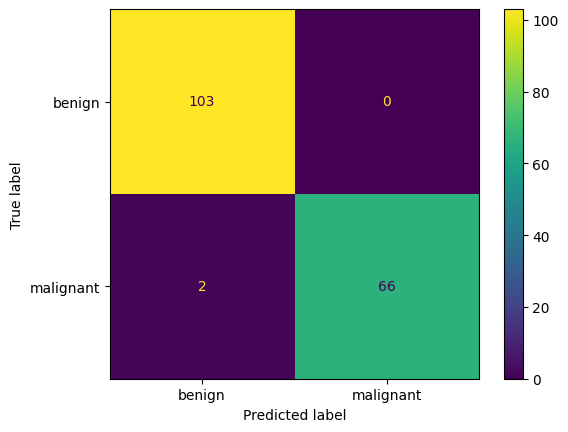

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred)
cmd = ConfusionMatrixDisplay(cm, display_labels=['benign', 'malignant'])
cmd.plot()

In [19]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           B       0.98      1.00      0.99       103
           M       1.00      0.97      0.99        68

    accuracy                           0.99       171
   macro avg       0.99      0.99      0.99       171
weighted avg       0.99      0.99      0.99       171



## Evaluation - Nur

## Deployment - Anni